Встановлення бібліотек

In [ ]:
import kagglehub
import os
import shutil
import pandas as pd
import cv2
from pathlib import Path
import yaml


завантаження датасеті

In [ ]:
#(Dental Radiography)
path_ds1 = kagglehub.dataset_download("imtkaggleteam/dental-radiography")
base_ds1 = Path(path_ds1) / "dental_radiography"

#(Dental OPG)
path_ds2 = kagglehub.dataset_download("imtkaggleteam/dental-opg-xray-dataset")
base_ds2 = Path(path_ds2) / "Dental OPG XRAY Dataset/Dental OPG (Object Detection)/Augmented Dataset"

print(f"DS1 path: {base_ds1}")
print(f"DS2 path: {base_ds2}")


Using Colab cache for faster access to the 'dental-radiography' dataset.
Using Colab cache for faster access to the 'dental-opg-xray-dataset' dataset.
DS1 path: /kaggle/input/dental-radiography/dental_radiography
DS2 path: /kaggle/input/dental-opg-xray-dataset/Dental OPG XRAY Dataset/Dental OPG (Object Detection)/Augmented Dataset


Проводимо налаштування класів

Цільові класи: 0=Caries, 1=Impacted, 2=Fracture

In [ ]:

DS1_MAP = {
    'Cavity': 0,
    'Impacted Tooth': 1,
    'Fillings': None,
    'Implant': None,
    '__background__': None
}

DS2_MAP = {
    0: None, # Healthy
    1: 0,    # Caries -> Caries
    2: 1,    # Impacted -> Impacted
    3: 2,    # Broken -> Fracture
    4: None, # Infection (ігноруємо)
    5: 2     # Fractured -> Fracture
}

YOLO

In [ ]:
import yaml
import shutil
import cv2
import pandas as pd
from pathlib import Path

def create_yolo_dataset(output_path):
    output_path = Path(output_path)

    if output_path.exists():
        shutil.rmtree(output_path)

    for split in ['train', 'valid']:
        (output_path / split / 'images').mkdir(parents=True, exist_ok=True)
        (output_path / split / 'labels').mkdir(parents=True, exist_ok=True)

    # Dataset 1 (Radiography)
    for split in ['train', 'valid']:
        csv_file = base_ds1 / split / '_annotations.csv'
        if not csv_file.exists(): continue

        df = pd.read_csv(csv_file)

        for filename, group in df.groupby('filename'):
            src_img_path = base_ds1 / split / filename
            if not src_img_path.exists(): continue

            img = cv2.imread(str(src_img_path))
            if img is None: continue
            h, w = img.shape[:2]

            yolo_labels = []
            for _, row in group.iterrows():
                cls_name = row['class']
                if cls_name not in DS1_MAP or DS1_MAP[cls_name] is None:
                    continue

                cls_id = DS1_MAP[cls_name]

                # Конвертація
                dw = 1. / w
                dh = 1. / h
                x_center = (row['xmin'] + row['xmax']) / 2.0 * dw
                y_center = (row['ymin'] + row['ymax']) / 2.0 * dh
                width = (row['xmax'] - row['xmin']) * dw
                height = (row['ymax'] - row['ymin']) * dh

                yolo_labels.append(f"{cls_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")

            if yolo_labels:
                new_filename = f"ds1_{filename}"
                shutil.copy(src_img_path, output_path / split / 'images' / new_filename)
                txt_path = output_path / split / 'labels' / new_filename.replace('.jpg', '.txt').replace('.png', '.txt')
                with open(txt_path, 'w') as f:
                    f.write('\n'.join(yolo_labels))

    # Dataset 2 (OPG)
    ds2_split_map = {'train': 'train', 'valid': 'valid', 'test': 'valid'}
    for src_split, dst_split in ds2_split_map.items():
        img_dir = base_ds2 / src_split / 'images'
        lbl_dir = base_ds2 / src_split / 'labels'

        if not img_dir.exists(): continue

        for img_file in img_dir.glob('*.*'): # .jpg або .png
            txt_file = lbl_dir / f"{img_file.stem}.txt"
            if not txt_file.exists(): continue

            with open(txt_file, 'r') as f:
                lines = f.readlines()

            new_lines = []
            for line in lines:
                parts = line.strip().split()
                orig_id = int(parts[0])

                # Перевіряємо чи потрібен цей клас і міняємо ID
                if orig_id in DS2_MAP and DS2_MAP[orig_id] is not None:
                    new_id = DS2_MAP[orig_id]
                    # Збираємо рядок назад з новим ID
                    new_lines.append(f"{new_id} {' '.join(parts[1:])}")

            if new_lines:
                new_filename = f"ds2_{img_file.name}"
                shutil.copy(img_file, output_path / dst_split / 'images' / new_filename)
                new_txt_path = output_path / dst_split / 'labels' / f"ds2_{img_file.stem}.txt"
                with open(new_txt_path, 'w') as f:
                    f.write('\n'.join(new_lines))

    # Створюємо dataset.yaml
    yaml_content = {
        'path': str(output_path.absolute()),
        'train': 'train/images',
        'val': 'valid/images',
        'nc': 3,
        'names': ['Caries', 'Impacted', 'Fracture']
    }
    with open(output_path / 'dataset.yaml', 'w') as f:
        yaml.dump(yaml_content, f)


create_yolo_dataset("/content/dataset_yolo")

print('+++++++++++')

+++++++++++


Format: CSV / Pascal VOC style

In [ ]:
!pip install -q kagglehub opencv-python pandas

import kagglehub
import shutil
import pandas as pd
import cv2
import os
from pathlib import Path

# 1. Підготовка шляхів (щоб уникнути FileNotFoundError)
path_ds1_dl = kagglehub.dataset_download("imtkaggleteam/dental-radiography")
path_ds2_dl = kagglehub.dataset_download("imtkaggleteam/dental-opg-xray-dataset")

# Автоматичний пошук кореневих папок
try:
    base_ds1 = list(Path(path_ds1_dl).rglob('_annotations.csv'))[0].parent.parent
    base_ds2 = list(Path(path_ds2_dl).rglob('Augmented Dataset'))[0]
except IndexError:
    # Запасний варіант, якщо структура відрізняється
    base_ds1 = Path(path_ds1_dl) / "dental_radiography"
    base_ds2 = Path(path_ds2_dl) / "Dental OPG XRAY Dataset/Dental OPG (Object Detection)/Augmented Dataset"

# 2. Налаштування 
DS1_MAP = {'Cavity': 0, 'Impacted Tooth': 1, 'Fillings': None, 'Implant': None, '__background__': None}
DS2_MAP = {0: None, 1: 0, 2: 1, 3: 2, 4: None, 5: 2}
ID_TO_NAME = {0: 'Caries', 1: 'Impacted', 2: 'Fracture'}

# 3. Функція генерації
def create_standard_dataset(output_path):
    output_path = Path(output_path)

    if output_path.exists():
        shutil.rmtree(output_path)

    for split in ['train', 'valid']:
        (output_path / split).mkdir(parents=True, exist_ok=True)

    for split in ['train', 'valid']:
        new_rows = []

        #  Processing Dataset 1 
        csv_file = base_ds1 / split / '_annotations.csv'
        if csv_file.exists():
            df = pd.read_csv(csv_file)
            for _, row in df.iterrows():
                if row['class'] in DS1_MAP and DS1_MAP[row['class']] is not None:
                    cls_id = DS1_MAP[row['class']]
                    new_filename = f"ds1_{row['filename']}"

                    src_img = base_ds1 / split / row['filename']
                    dst_img = output_path / split / new_filename

                    if src_img.exists():
                        if not dst_img.exists():
                            shutil.copy(src_img, dst_img)

                        new_rows.append({
                            'filename': new_filename,
                            'width': row['width'], 'height': row['height'],
                            'class': ID_TO_NAME[cls_id],
                            'xmin': row['xmin'], 'ymin': row['ymin'],
                            'xmax': row['xmax'], 'ymax': row['ymax']
                        })

        #  Processing Dataset 2 
        ds2_splits = ['train'] if split == 'train' else ['valid', 'test']
        for ds2_split in ds2_splits:
            img_dir = base_ds2 / ds2_split / 'images'
            lbl_dir = base_ds2 / ds2_split / 'labels'

            if img_dir.exists():
                for img_file in img_dir.glob('*.*'):
                    txt_file = lbl_dir / f"{img_file.stem}.txt"
                    if txt_file.exists():
                        img = cv2.imread(str(img_file))
                        if img is None: continue
                        h, w = img.shape[:2]

                        with open(txt_file, 'r') as f:
                            lines = f.readlines()

                        valid_obj = False
                        temp_objs = []
                        for line in lines:
                            parts = line.strip().split()
                            orig_id = int(parts[0])

                            if orig_id in DS2_MAP and DS2_MAP[orig_id] is not None:
                                new_id = DS2_MAP[orig_id]
                                x_c, y_c, bw, bh = map(float, parts[1:])

                                xmin = int((x_c - bw / 2) * w)
                                ymin = int((y_c - bh / 2) * h)
                                xmax = int((x_c + bw / 2) * w)
                                ymax = int((y_c + bh / 2) * h)

                                temp_objs.append({
                                    'filename': f"ds2_{img_file.name}",
                                    'width': w, 'height': h,
                                    'class': ID_TO_NAME[new_id],
                                    'xmin': max(0, xmin), 'ymin': max(0, ymin),
                                    'xmax': min(w, xmax), 'ymax': min(h, ymax)
                                })
                                valid_obj = True

                        if valid_obj:
                            dst_img = output_path / split / f"ds2_{img_file.name}"
                            if not dst_img.exists():
                                shutil.copy(img_file, dst_img)
                            new_rows.extend(temp_objs)

        if new_rows:
            df_out = pd.DataFrame(new_rows)

            cols = ['filename', 'width', 'height', 'class', 'xmin', 'ymin', 'xmax', 'ymax']
            df_out = df_out[cols]
            df_out.to_csv(output_path / split / '_annotations.csv', index=False)


create_standard_dataset("/content/dataset_standard")
print('+++++++++++ DONE +++++++++++')

Using Colab cache for faster access to the 'dental-radiography' dataset.
Using Colab cache for faster access to the 'dental-opg-xray-dataset' dataset.
+++++++++++ DONE +++++++++++


# **Аналіз Даних**



In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import cv2
import numpy as np
from pathlib import Path

# Шлях до згенерованого CSV
DATA_DIR = Path("/content/dataset_standard/train")
CSV_PATH = DATA_DIR / "_annotations.csv"

# Налаштування стилю
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

if CSV_PATH.exists():
    df = pd.read_csv(CSV_PATH)
    print(f"Data loaded successfully.")
    print(f"Total annotations: {len(df)}")
    print(f"Unique images: {df['filename'].nunique()}")
    display(df.head(3))
else:
    print(f"Error: File not found at {CSV_PATH}")
    print("Ensure create_standard_dataset() execution completed successfully.")

Data loaded successfully.
Total annotations: 5267
Unique images: 995


,filename,width,height,class,xmin,ymin,xmax,ymax
0,ds1_0412_jpg.rf.e27f70cf0b5eb7dbe5164773540f87...,512,256,Impacted,374,68,403,99
1,ds1_0412_jpg.rf.e27f70cf0b5eb7dbe5164773540f87...,512,256,Impacted,131,70,164,105
2,ds1_0801_jpg.rf.e3e799ad12fe11d78469e18456264b...,512,256,Caries,176,75,200,105


Завдяки цій частинці бачимо що ми змогли обєднати сет і він класно насичений. Наступний крок оцінити розподіл

/tmp/ipython-input-2955880783.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


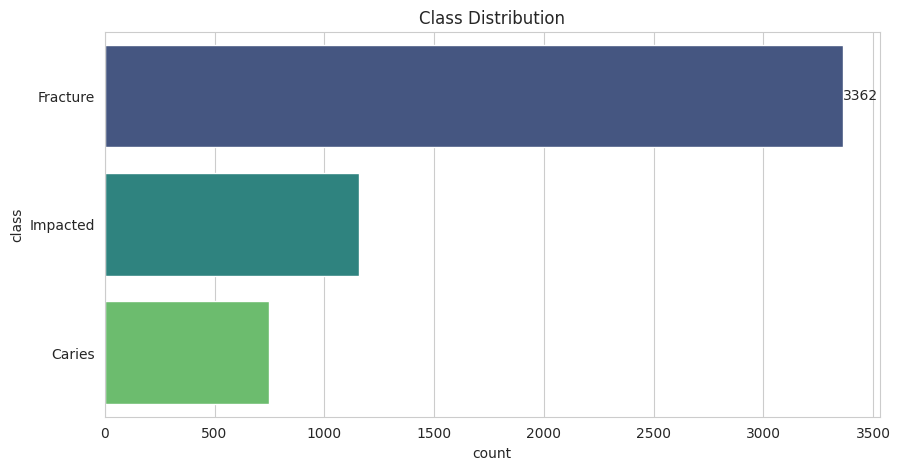

In [ ]:
if 'df' in locals():
    plt.figure(figsize=(10, 5))
    ax = sns.countplot(
        y="class",
        data=df,
        order=df['class'].value_counts().index,
        palette="viridis"
    )

    ax.set_title("Class Distribution")
    ax.bar_label(ax.containers[0])
    plt.show()

Цей графік розкриває дуже важливу, і, чесно кажучи, трохи небезпечну ситуацію для навчання моделі. У нас нерівнімірний розподіл даних. Це не смертельно, але це треба тримати в голові, коли будете дивитись на результати навчання. Якщо модель буде погано справлятися з карієсом ми знаємо чому

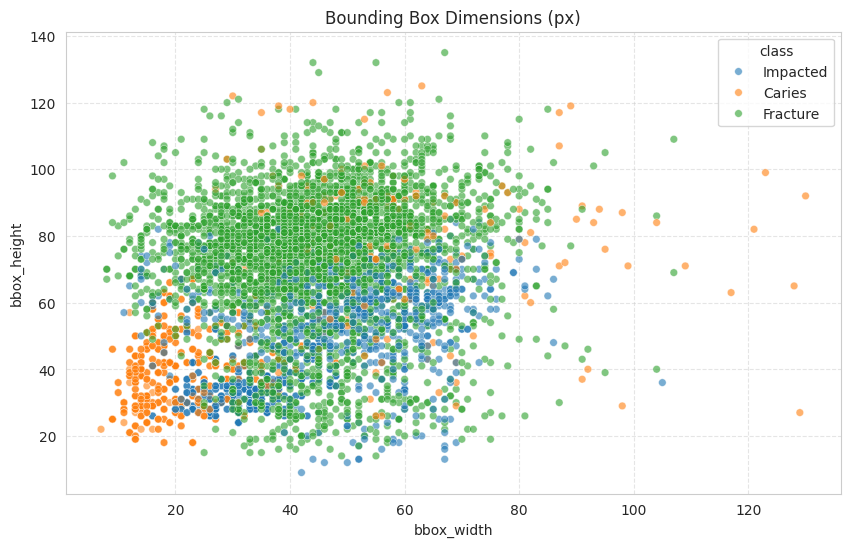

In [ ]:
if 'df' in locals():

    df['bbox_width'] = df['xmax'] - df['xmin']
    df['bbox_height'] = df['ymax'] - df['ymin']

    plt.figure(figsize=(10, 6))


    sns.scatterplot(
        data=df,
        x='bbox_width',
        y='bbox_height',
        hue='class',
        alpha=0.6,
        s=30
    )

    plt.title("Bounding Box Dimensions (px)")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

Тут ми можемо бачити розміри рамок. Каріас, якого у нас найменше, є й щей найменш помітними проблемами (маленькі плямки). Тому при побудові моделі, треба бути обережними при зменшені зображення

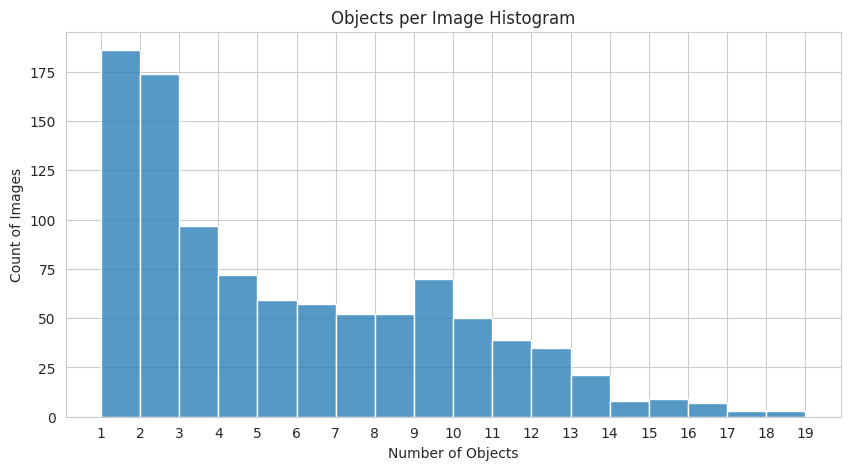

In [ ]:
if 'df' in locals():
    objects_per_image = df.groupby('filename').size()

    plt.figure(figsize=(10, 5))
    sns.histplot(objects_per_image, bins=range(1, 20), kde=False)

    plt.title("Objects per Image Histogram")
    plt.xlabel("Number of Objects")
    plt.ylabel("Count of Images")
    plt.xticks(range(1, 20))
    plt.show()

На графіку кількості патологій, бачимо що у більшості 1-2 але є також складніші випадки де є >5, що дозволить краще навчитися розрізняти патології

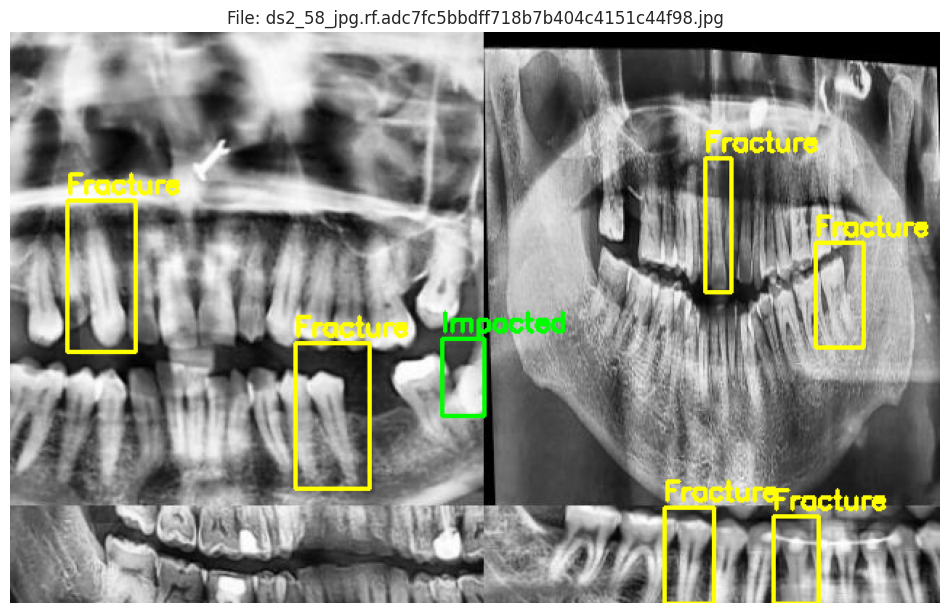

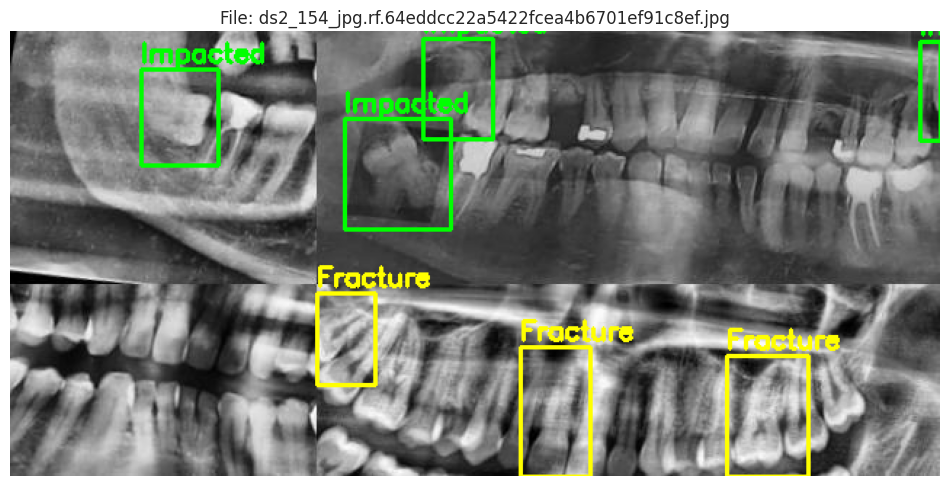

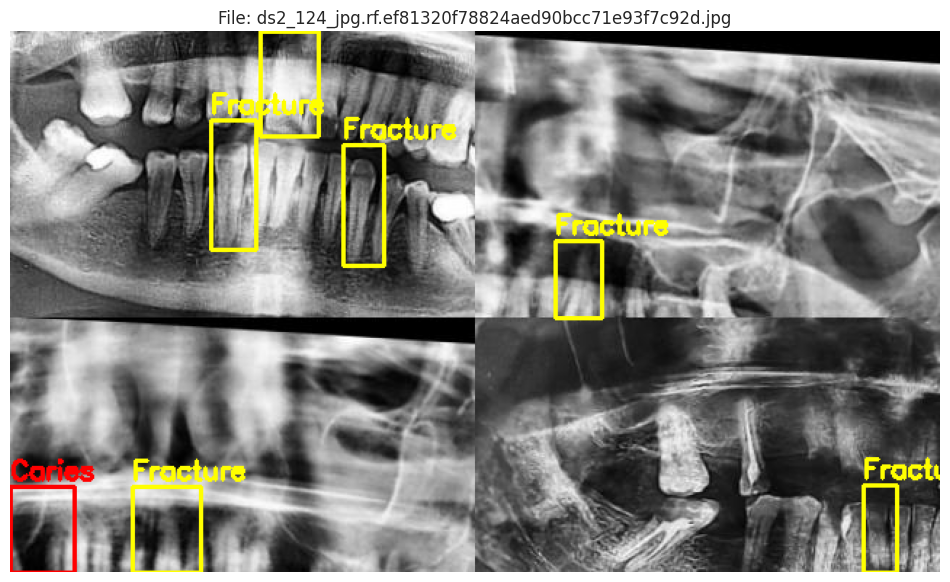

In [ ]:
def show_sample(filename):
    img_path = DATA_DIR / filename
    if not img_path.exists():
        print(f"Image not found: {filename}")
        return

    image = cv2.imread(str(img_path))
    if image is None: return
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    records = df[df['filename'] == filename]

    for _, row in records.iterrows():
        start = (int(row['xmin']), int(row['ymin']))
        end = (int(row['xmax']), int(row['ymax']))

        # Caries: Red, Impacted: Green, Fracture: Yellow
        if row['class'] == 'Caries': color = (255, 0, 0)
        elif row['class'] == 'Impacted': color = (0, 255, 0)
        else: color = (255, 255, 0)

        cv2.rectangle(image, start, end, color, 2)
        cv2.putText(image, row['class'], (start[0], start[1]-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    plt.figure(figsize=(12, 8))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"File: {filename}")
    plt.show()

if 'df' in locals():
    # Вибірка 3 випадкових файлів
    random_samples = df['filename'].sample(3).values
    for f in random_samples:
        show_sample(f)

З основних висновків


1.   Є дисбаланс, тому в разі поганої детекції карієсу варто буде приймати рішення
2.   Обережно з зменшенням зображення

